In [30]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from datetime import datetime
from pandas.tseries.offsets import MonthBegin

sns.set_theme(style="whitegrid")

plt.rcParams["figure.figsize"]=(12,6)
plt.rcParams["axes.titlesize"]=15
plt.rcParams["axes.labelsize"]=12
plt.rcParams["legend.fontsize"]=11
plt.rcParams["figure.dpi"]=120

df = pd.read_excel("/home/mahaputra777/pt_skp/dataset/pp_may_june_2026.xls")

print(df.shape)

df.info()

(1598, 31)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1598 entries, 0 to 1597
Data columns (total 31 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Reservation Date  1598 non-null   object 
 1   Folio             1598 non-null   int64  
 2   Reference No      879 non-null    object 
 3   Room Type         1598 non-null   object 
 4   Room              1597 non-null   object 
 5   Rates             1598 non-null   object 
 6   Guest             1598 non-null   object 
 7   Date of Birth     0 non-null      float64
 8   Guest Email       991 non-null    object 
 9   Nationality       490 non-null    object 
 10  Country           1369 non-null   object 
 11  Province          0 non-null      float64
 12  City              0 non-null      float64
 13  Arrival           1598 non-null   object 
 14  Departure         1598 non-null   object 
 15  Nights            1598 non-null   int64  
 16  Agent             1598 non-null

In [31]:
df["Reservation Date"] = pd.to_datetime(df["Reservation Date"])
df["Arrival"] = pd.to_datetime(df["Arrival"])
df["Departure"] = pd.to_datetime(df["Departure"])

In [32]:
from pandas.tseries.offsets import MonthEnd

# ==========================================
# Analysis Period
# ==========================================

selected_year = 2026
selected_month = 5      # 4=April, 5=May, 6=June

analysis_start = pd.Timestamp(
    year=selected_year,
    month=selected_month,
    day=1
)

analysis_end = analysis_start + MonthEnd(0)

month_name = analysis_start.strftime("%B")

print("="*50)
print(f"Analysis Month : {month_name} {selected_year}")
print(f"Data Included  : <= {analysis_end.date()}")
print("="*50)

# Dataset histori hingga akhir bulan analisis
df_report = df[
    df["Arrival"] <= analysis_end
].copy()

# Dataset khusus bulan yang dipilih
df_month = df[
    (df["Arrival"].dt.year == selected_year) &
    (df["Arrival"].dt.month == selected_month)
].copy()

Analysis Month : May 2026
Data Included  : <= 2026-05-31


1. Pertumbuhan Room Night (Overall vs Bulan)

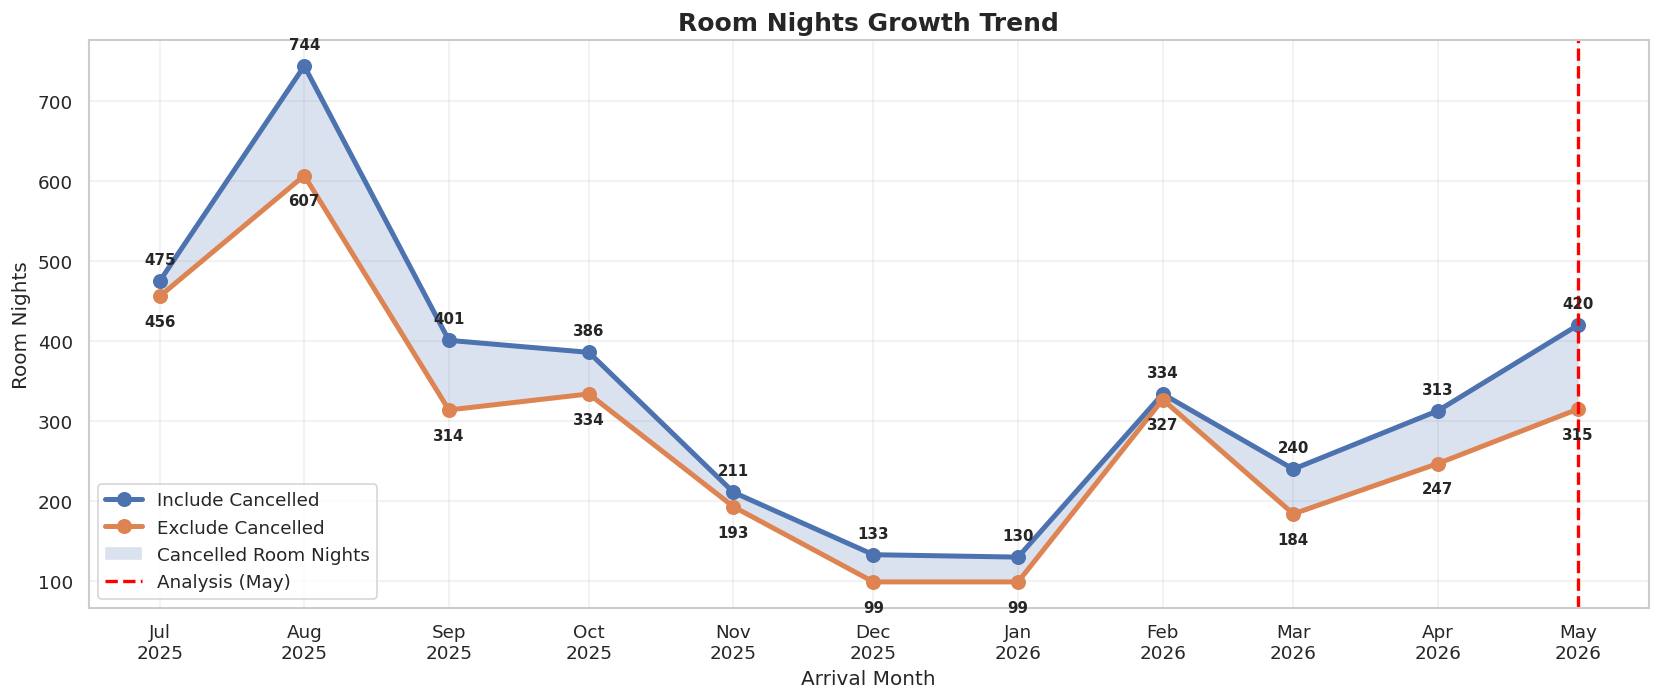

In [33]:
# ==========================================
# Room Nights Growth Trend
# ==========================================

room_nights_all = (
    df_report
    .groupby(df_report["Arrival"].dt.to_period("M"))["Nights"]
    .sum()
)

room_nights_live = (
    df_report[df_report["Status"] != "CANCELLED"]
    .groupby(
        df_report[df_report["Status"] != "CANCELLED"]["Arrival"].dt.to_period("M")
    )["Nights"]
    .sum()
)

room_nights_all.index = room_nights_all.index.to_timestamp()
room_nights_live.index = room_nights_live.index.to_timestamp()

trend = pd.DataFrame({
    "Include Cancelled": room_nights_all,
    "Exclude Cancelled": room_nights_live
}).fillna(0)

plt.figure(figsize=(14,6))

plt.plot(
    trend.index,
    trend["Include Cancelled"],
    marker="o",
    linewidth=3,
    markersize=8,
    label="Include Cancelled"
)

plt.plot(
    trend.index,
    trend["Exclude Cancelled"],
    marker="o",
    linewidth=3,
    markersize=8,
    label="Exclude Cancelled"
)

plt.fill_between(
    trend.index,
    trend["Exclude Cancelled"],
    trend["Include Cancelled"],
    alpha=0.20,
    label="Cancelled Room Nights"
)

# Label Include Cancelled
for x, y in zip(trend.index, trend["Include Cancelled"]):
    plt.annotate(
        f"{int(y)}",
        (x, y),
        xytext=(0, 10),
        textcoords="offset points",
        ha="center",
        fontsize=9,
        fontweight="bold"
    )

# Label Exclude Cancelled
for x, y in zip(trend.index, trend["Exclude Cancelled"]):
    plt.annotate(
        f"{int(y)}",
        (x, y),
        xytext=(0, -18),
        textcoords="offset points",
        ha="center",
        fontsize=9,
        fontweight="bold"
    )

# Garis bulan analisis
plt.axvline(
    analysis_start,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Analysis ({month_name})"
)

plt.title(
    "Room Nights Growth Trend",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Arrival Month")
plt.ylabel("Room Nights")

plt.grid(alpha=.3)

plt.legend()

plt.xticks(
    trend.index,
    trend.index.strftime("%b\n%Y")
)

plt.tight_layout()

plt.show()

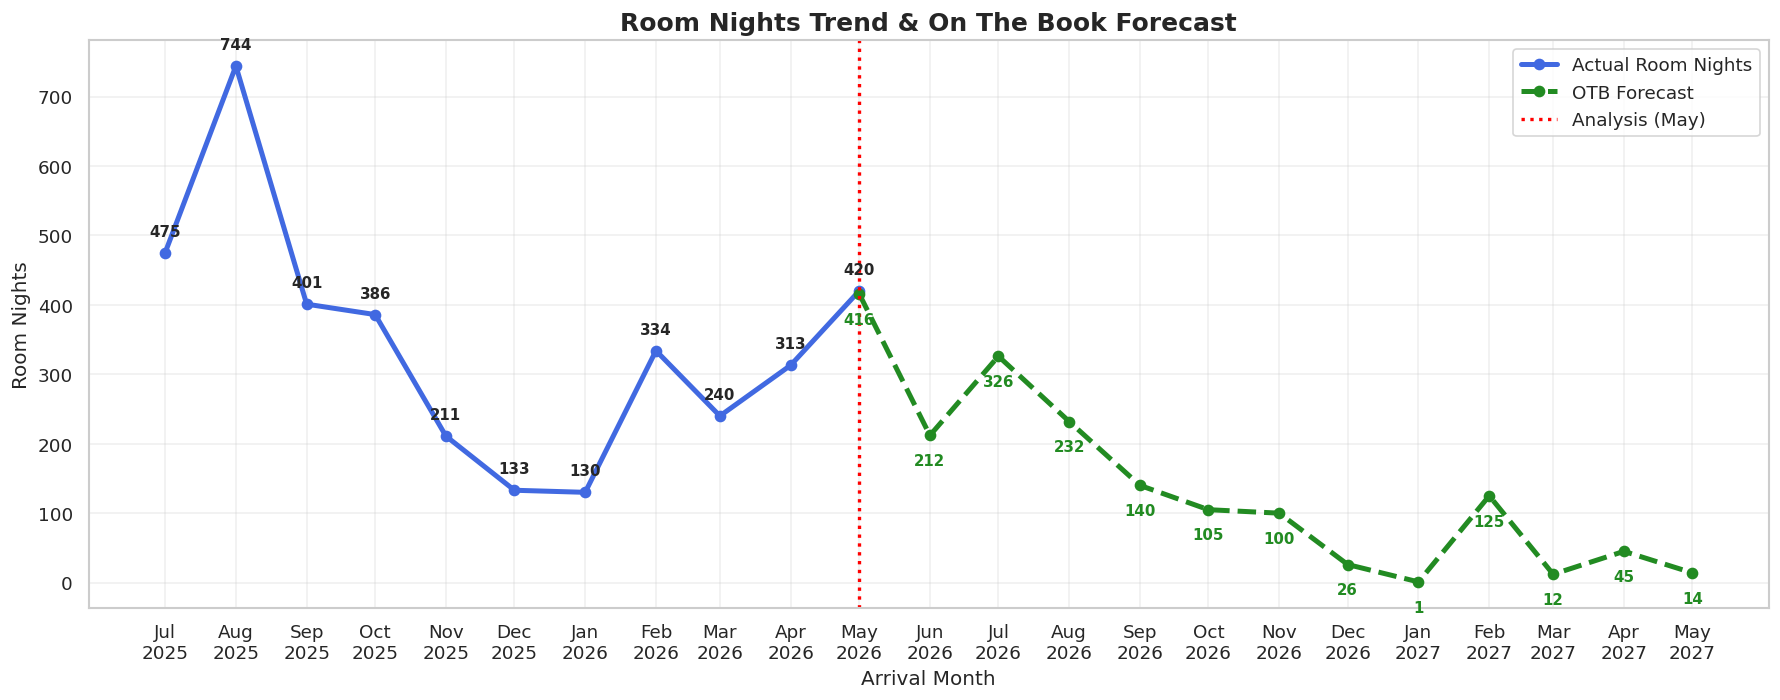

In [34]:
# ==========================================
# Room Nights Trend (Actual + Forecast)
# ==========================================

# Actual (sampai bulan analisis)
actual = (
    df_report
    .groupby(df_report["Arrival"].dt.to_period("M"))["Nights"]
    .sum()
)

actual.index = actual.index.to_timestamp()

# Forecast (booking yang sudah masuk)
forecast = (
    df[
        df["Reservation Date"] <= analysis_end
    ]
    .groupby(
        df[df["Reservation Date"] <= analysis_end]["Arrival"].dt.to_period("M")
    )["Nights"]
    .sum()
)

forecast.index = forecast.index.to_timestamp()

plt.figure(figsize=(15,6))

# =====================
# Actual
# =====================

plt.plot(
    actual.index,
    actual.values,
    marker="o",
    linewidth=3,
    color="royalblue",
    label="Actual Room Nights"
)

# =====================
# Forecast
# =====================

future = forecast[
    forecast.index >= analysis_start
]

plt.plot(
    future.index,
    future.values,
    marker="o",
    linestyle="--",
    linewidth=3,
    color="forestgreen",
    label="OTB Forecast"
)

# =====================
# Label
# =====================

for x,y in zip(actual.index,actual.values):

    plt.annotate(
        f"{int(y)}",
        (x,y),
        xytext=(0,10),
        textcoords="offset points",
        ha="center",
        fontsize=9,
        fontweight="bold"
    )

for x,y in zip(future.index,future.values):

    plt.annotate(
        f"{int(y)}",
        (x,y),
        xytext=(0,-18),
        textcoords="offset points",
        ha="center",
        fontsize=9,
        fontweight="bold",
        color="forestgreen"
    )

# =====================
# Analysis Line
# =====================

plt.axvline(
    analysis_start,
    color="red",
    linestyle=":",
    linewidth=2,
    label=f"Analysis ({month_name})"
)

plt.title(
    "Room Nights Trend & On The Book Forecast",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Arrival Month")
plt.ylabel("Room Nights")

plt.grid(alpha=.3)

plt.legend()

plt.xticks(
    forecast.index,
    forecast.index.strftime("%b\n%Y")
)

plt.tight_layout()

plt.show()

2. Performance Pick Up

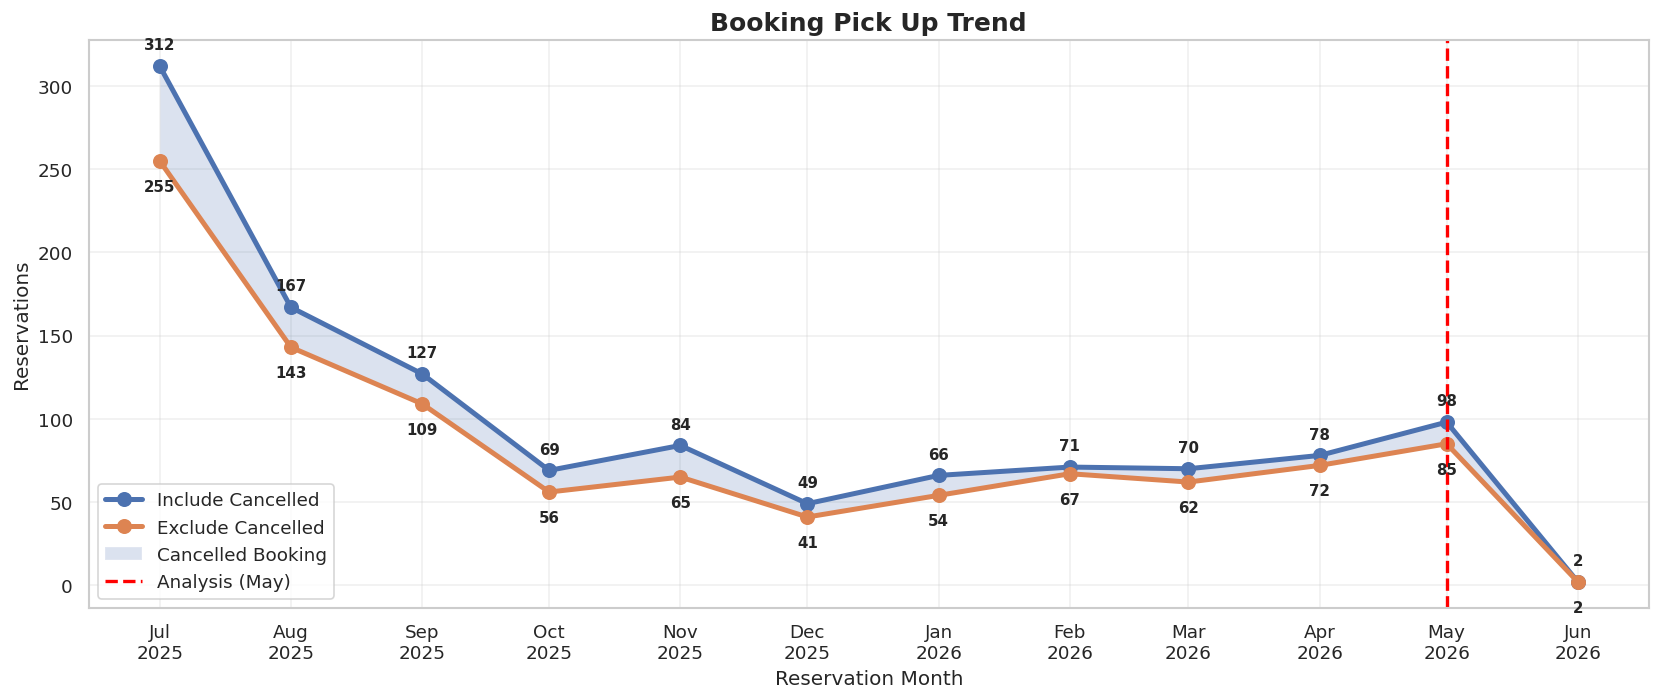

In [35]:
# ==========================================
# Booking Pick Up Trend
# (Based on Reservation Date)
# ==========================================

pickup_all = (
    df_report
    .groupby(df_report["Reservation Date"].dt.to_period("M"))
    .size()
)

pickup_live = (
    df_report[df_report["Status"] != "CANCELLED"]
    .groupby(
        df_report[df_report["Status"] != "CANCELLED"]["Reservation Date"].dt.to_period("M")
    )
    .size()
)

pickup_all.index = pickup_all.index.to_timestamp()
pickup_live.index = pickup_live.index.to_timestamp()

pickup = pd.DataFrame({
    "Include Cancelled": pickup_all,
    "Exclude Cancelled": pickup_live
}).fillna(0)

plt.figure(figsize=(14,6))

plt.plot(
    pickup.index,
    pickup["Include Cancelled"],
    marker="o",
    linewidth=3,
    markersize=8,
    label="Include Cancelled"
)

plt.plot(
    pickup.index,
    pickup["Exclude Cancelled"],
    marker="o",
    linewidth=3,
    markersize=8,
    label="Exclude Cancelled"
)

plt.fill_between(
    pickup.index,
    pickup["Exclude Cancelled"],
    pickup["Include Cancelled"],
    alpha=0.20,
    label="Cancelled Booking"
)

# Label Include Cancelled
for x, y in zip(pickup.index, pickup["Include Cancelled"]):
    plt.annotate(
        f"{int(y)}",
        (x, y),
        xytext=(0, 10),
        textcoords="offset points",
        ha="center",
        fontsize=9,
        fontweight="bold"
    )

# Label Exclude Cancelled
for x, y in zip(pickup.index, pickup["Exclude Cancelled"]):
    plt.annotate(
        f"{int(y)}",
        (x, y),
        xytext=(0, -18),
        textcoords="offset points",
        ha="center",
        fontsize=9,
        fontweight="bold"
    )

# Garis bulan analisis
plt.axvline(
    analysis_start,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Analysis ({month_name})"
)

plt.title(
    "Booking Pick Up Trend",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Reservation Month")
plt.ylabel("Reservations")

plt.grid(alpha=.3)

plt.legend()

plt.xticks(
    pickup.index,
    pickup.index.strftime("%b\n%Y")
)

plt.tight_layout()

plt.show()

3. Booking Window

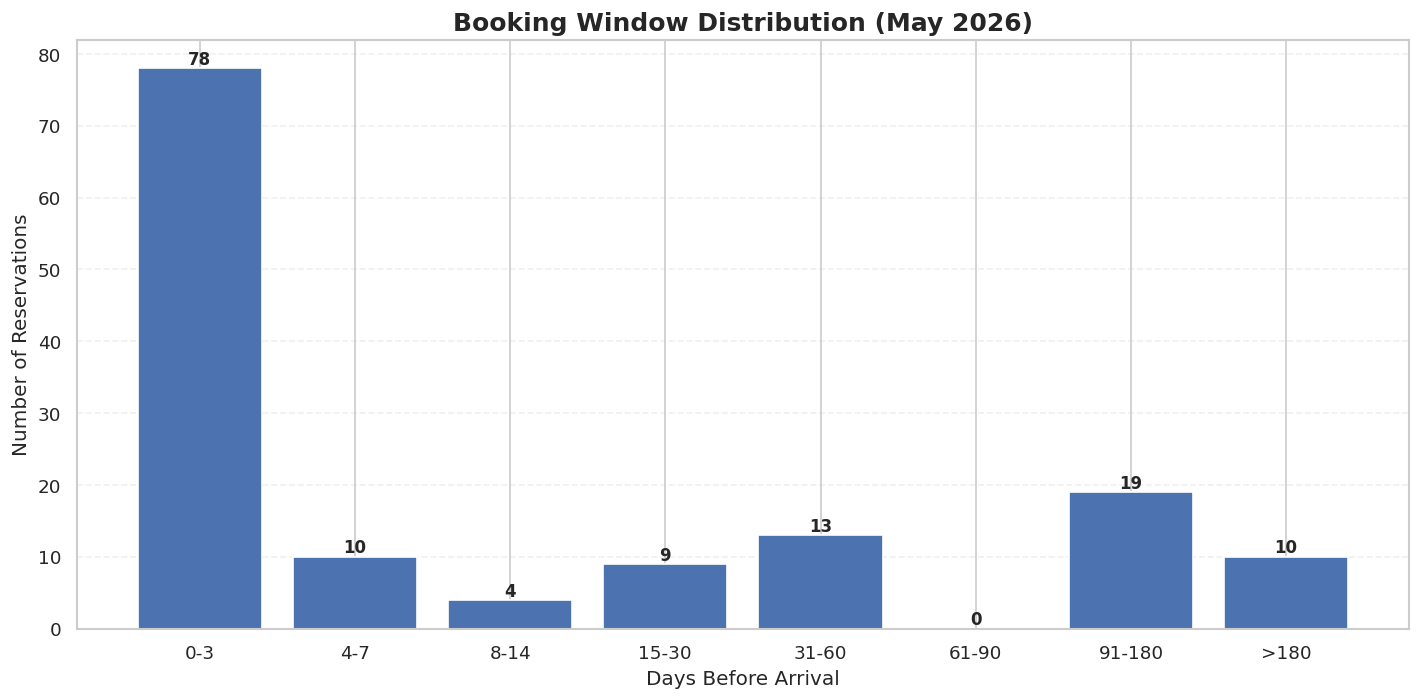

In [36]:
# ==========================================
# Booking Window Distribution (Bucket)
# ==========================================

lead = (
    df_month["Arrival"] -
    df_month["Reservation Date"]
).dt.days

lead = lead.dropna()
lead = lead[lead >= 0]

bins = [-1, 3, 7, 14, 30, 60, 90, 180, 9999]

labels = [
    "0-3",
    "4-7",
    "8-14",
    "15-30",
    "31-60",
    "61-90",
    "91-180",
    ">180"
]

booking_window = pd.cut(
    lead,
    bins=bins,
    labels=labels
).value_counts().sort_index()

plt.figure(figsize=(12,6))

bars = plt.bar(
    booking_window.index.astype(str),
    booking_window.values
)

# Label angka
for bar in bars:

    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{int(height)}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

plt.title(
    f"Booking Window Distribution ({month_name} {selected_year})",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Days Before Arrival")
plt.ylabel("Number of Reservations")

plt.grid(axis="y", linestyle="--", alpha=.3)

plt.tight_layout()

plt.show()

In [37]:
print(lead.describe())

count    143.000000
mean      42.384615
std       70.222977
min        0.000000
25%        1.000000
50%        3.000000
75%       41.000000
max      254.000000
dtype: float64


4. Negara yang Stay Bulan Itu vs Overall

In [ ]:
# ==========================================
# Country Comparison
# (Overall <= Analysis Month)
# ==========================================

overall_country = (
    df_report
    .groupby("Country")
    .size()
)

month_country = (
    df_month
    .groupby("Country")
    .size()
)

country_compare = (
    pd.concat(
        [
            overall_country.rename("Overall"),
            month_country.rename(month_name)
        ],
        axis=1
    )
    .fillna(0)
    .astype(int)
)

# Urutkan berdasarkan booking bulan analisis
country_compare = country_compare.sort_values(
    by=month_name,
    ascending=False
)

display(country_compare.head(15))

,Overall,May
Country,,
Australia,709,72
Indonesia,111,16
United States,45,6
Germany,46,5
France,50,5
New Zealand,48,3
United Kingdom,31,2
Portugal,3,2
Italy,34,2


5. Room Type Bulan Itu vs Overall

In [ ]:
# ==========================================
# Room Type Comparison
# (Overall <= Analysis Month)
# ==========================================

overall_room = (
    df_report
    .groupby("Room Type")
    .size()
)

month_room = (
    df_month
    .groupby("Room Type")
    .size()
)

room_compare = (
    pd.concat(
        [
            overall_room.rename("Overall"),
            month_room.rename(month_name)
        ],
        axis=1
    )
    .fillna(0)
    .astype(int)
)

# Urutkan berdasarkan booking bulan analisis
room_compare = room_compare.sort_values(
    by=month_name,
    ascending=False
)

display(room_compare)

,Overall,May
Room Type,,
Basic,305,34
Happy House,34,1
Joglo,60,6
River House,64,8
River Suite,1135,97


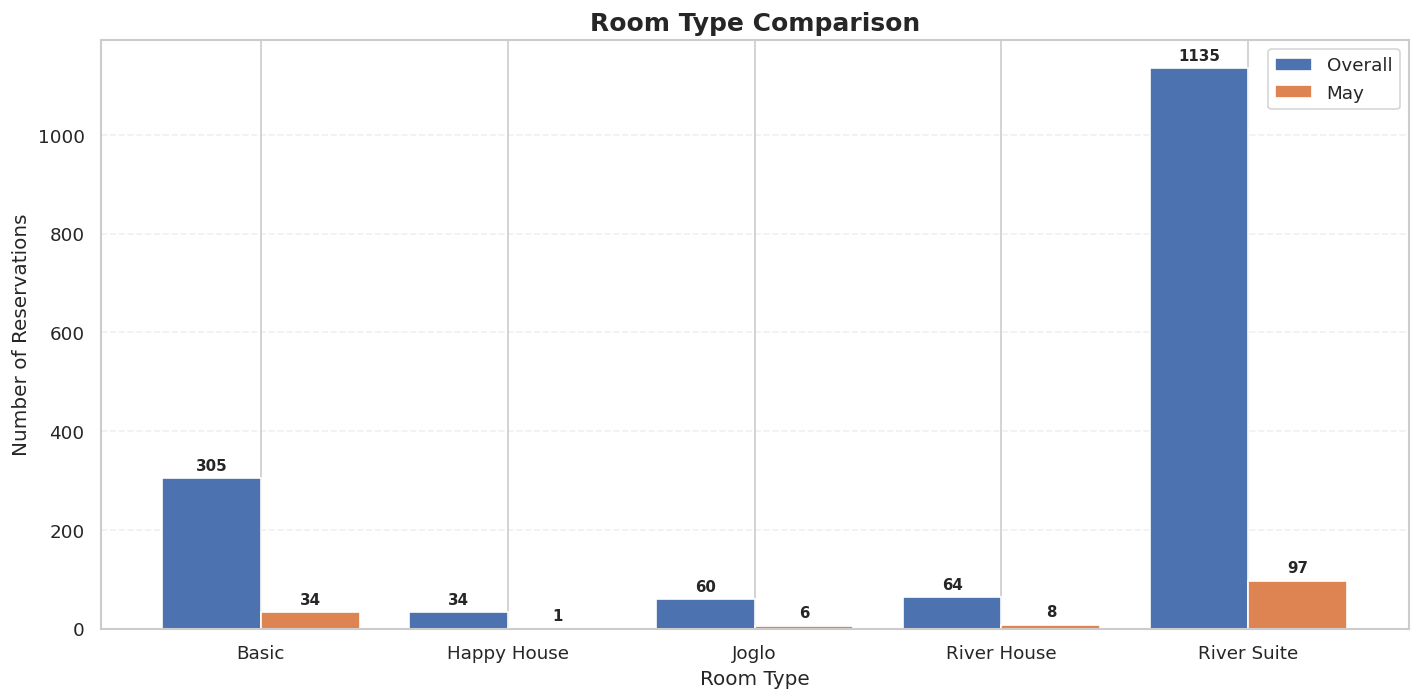

In [40]:
# ==========================================
# Room Type Comparison
# ==========================================

ax = room_compare.plot.bar(
    figsize=(12,6),
    width=0.8
)

# Tambahkan nilai di atas setiap batang
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.0f',
        padding=3,
        fontsize=9,
        fontweight='bold'
    )

plt.title(
    "Room Type Comparison",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Room Type")
plt.ylabel("Number of Reservations")

plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.xticks(rotation=0)

plt.tight_layout()

plt.show()

6. Website Performance

In [41]:
website = df_month[

    df_month["Agent"]=="Doku"

]

summary = {

"Booking":len(website),

"Revenue":website["Room Net"].sum(),

"Nights":website["Nights"].sum(),

"ADR":website["Room Net"].sum()/website["Nights"].sum()

}

summary

{'Booking': 4,
 'Revenue': 5450879.45087949,
 'Nights': 9,
 'ADR': 605653.2723199433}